### Data Exploration 

#### Import essential libraries!

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder 


In [2]:
df = pd.read_csv('../data/Breast_Cancer.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget distribution:")
print(df['Status'].value_counts())

Shape: (4024, 16)

First 5 rows:
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1          

In [ ]:
df.isna()
##if it return False, it means there is no missing value in the dataset.

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4021,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4022,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df['Age'].describe()

count    4024.000000
mean       53.972167
std         8.963134
min        30.000000
25%        47.000000
50%        54.000000
75%        61.000000
max        69.000000
Name: Age, dtype: float64

In [ ]:
df.isna().sum()
##it shows that there is no missing value in the dataset.

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [ ]:
df.duplicated().sum()
##it shows that there is no duplicated value in the dataset.

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)
#it drop the duplicated value in the dataset if there is any. In this case, there is no duplicated value in the dataset, so it will not drop any value.

In [ ]:
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


### One hot Encoding 

In [ ]:
cate_cols = ['Race', 
             'Marital status',
               'T Stage', 
               'N Stage', 
               'A Stage', 
               '6th Stage',
                 'Grade',
                   'Estrogen Status',
                   'Progesterone Status',
                     'HER2 Status', 
                     'Survival Status']



### Plot Histogram 
To see the the distribution of Age of having the Breast Cancer

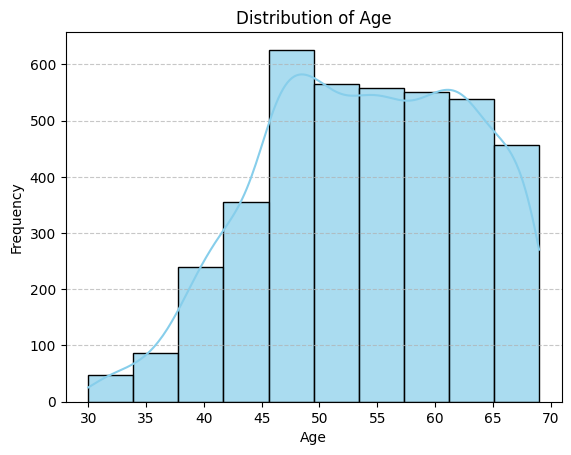

In [ ]:
sns.histplot(df['Age'], edgecolor='black', bins=10, color='skyblue', alpha=0.7, kde=True)


plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Plot Pie chart
We plot Pie Chart to show how different contribute to the whole dataset

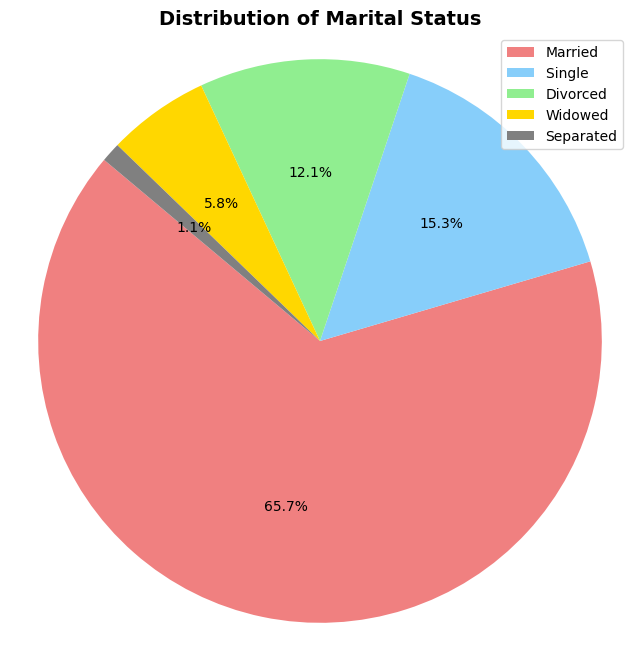

In [ ]:
size = df['Marital Status'].value_counts()
label = df['Marital Status'].value_counts().index

plt.figure(figsize=(8, 8))
plt.pie(size, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['lightcoral', 'lightskyblue', 'lightgreen', 'gold', 'gray'], 
        explode=(0, 0, 0, 0, 0),
        shadow=False)
plt.title('Distribution of Marital Status', color='Black', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.legend(labels=label, loc='upper right')
plt.show()      

### Plot the Count plot 
We plot the count plot to specifically see distribution of Race to the Breast Cancer


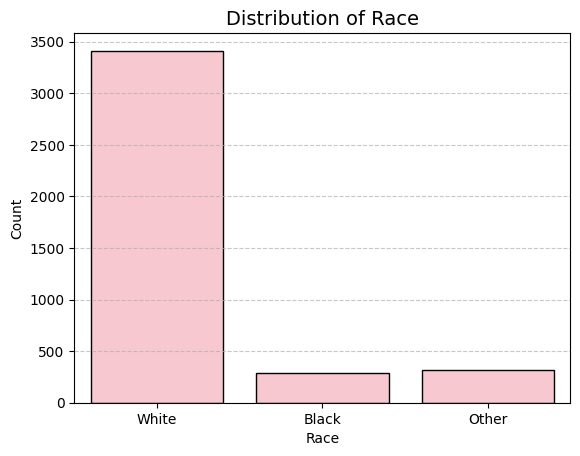

In [ ]:
df['Race'].value_counts()
sns.countplot(x='Race', data=df, color ='pink', edgecolor='black')
plt.title('Distribution of Race', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

It plot shows that White race seem to have higher chances of having Breast Cancer.

### Plot Heat Map/Confusion Matrix 
We plot the heat map to see the correlation between numerical features like Tumor size, Survival month,....

In [ ]:
df_numeric =df.select_dtypes(include=['number'])
df_numeric.corr()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
Age,1.000000,-0.077069,-0.033186,0.012743,-0.009224
Tumor Size,-0.077069,1.000000,0.104258,0.242247,-0.087016
Regional Node Examined,-0.033186,0.104258,1.000000,0.411520,-0.022166
Reginol Node Positive,0.012743,0.242247,0.411520,1.000000,-0.135330
Survival Months,-0.009224,-0.087016,-0.022166,-0.135330,1.000000


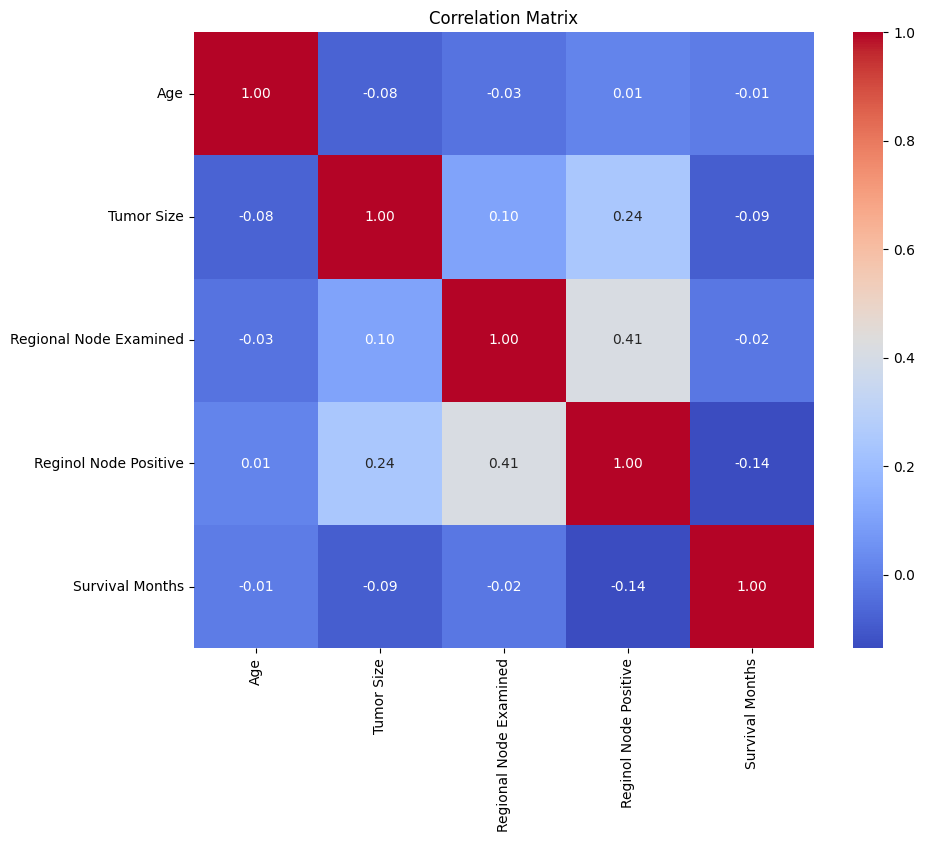

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#### VIF = Variance Inflation Factor 
We use VIF to detect the Multicolinearity
- VIF > 10 ---> Serious Multicolinearity, we need to drop out one feature and combine features together if needed (Regional Node Examined/Reginol Node Positive )
- VIF 5-10 ---> Moderate, it is okay to move on to the next step!
- VIF < 5  ---> Totally Fine, good to go!!

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 4023 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4023 non-null   int64
 1   Race                    4023 non-null   str  
 2   Marital Status          4023 non-null   str  
 3   T Stage                 4023 non-null   str  
 4   N Stage                 4023 non-null   str  
 5   6th Stage               4023 non-null   str  
 6   differentiate           4023 non-null   str  
 7   Grade                   4023 non-null   str  
 8   A Stage                 4023 non-null   str  
 9   Tumor Size              4023 non-null   int64
 10  Estrogen Status         4023 non-null   str  
 11  Progesterone Status     4023 non-null   str  
 12  Regional Node Examined  4023 non-null   int64
 13  Reginol Node Positive   4023 non-null   int64
 14  Survival Months         4023 non-null   int64
 15  Status                  4023 non-null

In [ ]:
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['Age', 
        'Tumor Size',
        'Regional Node Examined',
        'Reginol Node Positive', 
        'Survival Months']]

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

                  feature        VIF
0                     Age  11.168732
1              Tumor Size   3.076295
2  Regional Node Examined   4.741190
3   Reginol Node Positive   2.139869
4         Survival Months   8.732807


<Axes: >

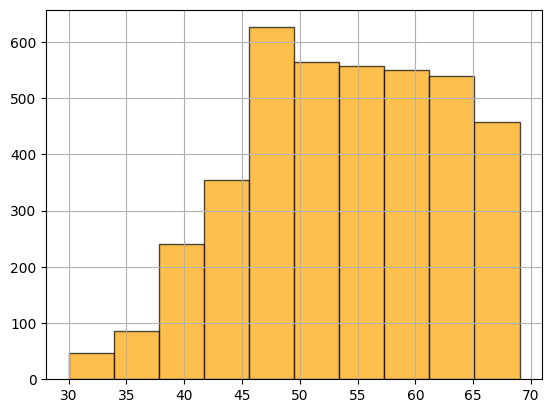

In [ ]:
df['Age'].hist(bins=10, edgecolor='black', color='orange', alpha=0.7)

In [ ]:
df[['Age', 'Tumor Size', 'Survival Months']].corr() 

,Age,Tumor Size,Survival Months
Age,1.000000,-0.077069,-0.009224
Tumor Size,-0.077069,1.000000,-0.087016
Survival Months,-0.009224,-0.087016,1.000000


The Age feature is likely to have a lot of outlier, idicating that the Age has high correlation with other variables in the model, not necessarily outliers in Age itself. Boxplots detect univariate outliers (extreme values in a single variable based on IQR), but VIF assesses how much Age is linearly dependent on the other predictors (e.g., it might correlate strongly with Survival Months or Tumor Size). This can inflate VIF even if Age's distribution looks normal without many outliers.

In this case, apply log on the Age which appears to be normally distributed, it could worsen the issues or introduce negative values/invalid data.
We can drop the Age, but Age in medical discovery is very important. 

Logging can reduce multicollinearity indirectly by:

- Compressing the scale of skewed variables — Many correlated features are correlated because they share an underlying exponential or multiplicative relationship (e.g., income and house size both grow multiplicatively). Log-transforming them converts multiplicative relationships into additive ones, which can reduce the correlation between them.
- Stabilizing variance — Features with high variance (often right-skewed) tend to dominate the model and create spurious correlations with other features. Logging compresses the upper tail, making the distributions more symmetric and comparably scaled.
- Linearizing relationships — If two features have a power-law relationship with each other (e.g., X₂ ≈ X₁²), they'll be highly correlated. After logging, log(X₂) ≈ 2·log(X₁), which is a linear relationship — and linear relationships between features are more "honest" for linear models to handle. Some regularization techniques also work better in this regime.

To reduce multicolinerity, we can use:
- Remove or combine correlated features (e.g., drop Age if redundant). In this case, we cannot drop the Age as the Age in medical discovery is very important. 
- Use dimensionality reduction like PCA.
- Apply regularization (e.g., Ridge regression) in modeling.

#### Distribution of each feature

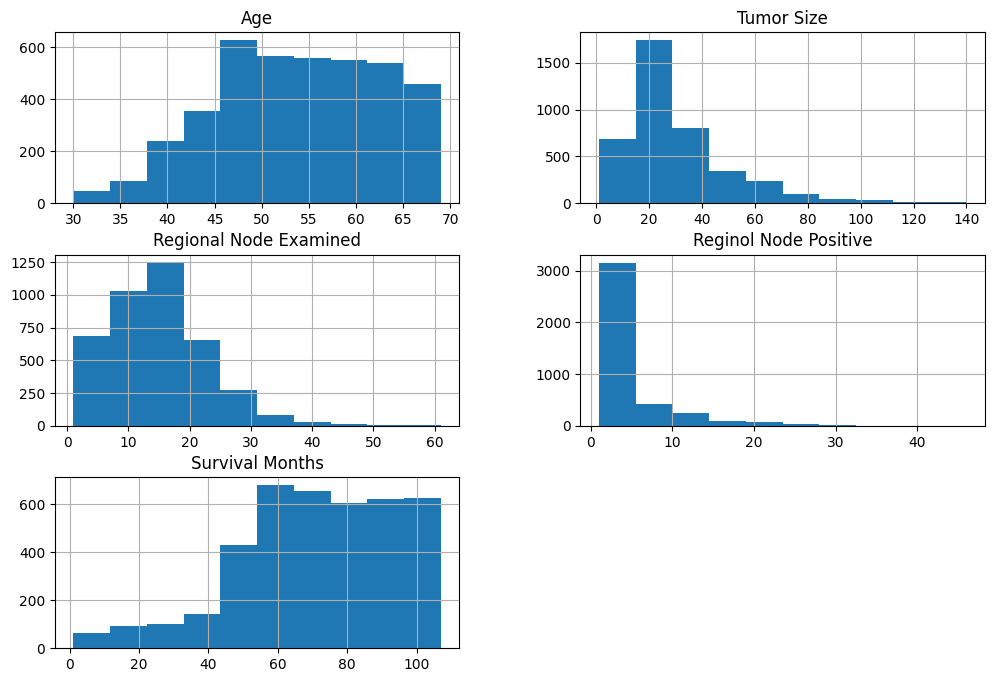

In [ ]:
# Distribution of each feature
df_numeric.hist(figsize=(12, 8), bins=10)
plt.show()


- The Age is not well distributed
- The Survival Month Feature is fairly uniform which mean good spread across time

But 
- The Tumor Size is Rigth skewed 
- The Regional Node Examined is Right Skewed 
- The Reginol Node Positive is Highly Right Skewed 


#### Check for outliers

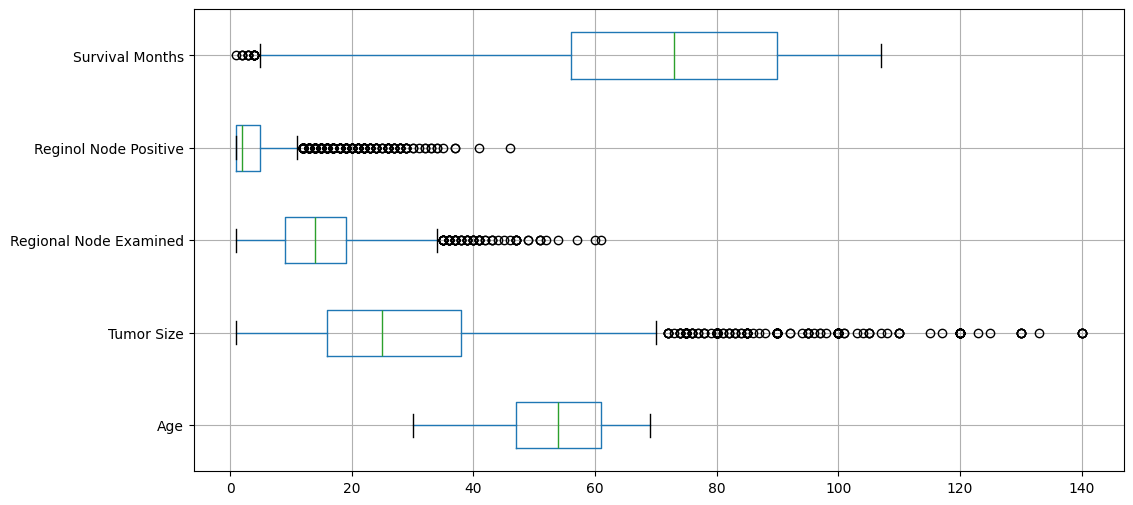

In [ ]:

df_numeric.boxplot(figsize=(12, 6), vert=False)

plt.show()

It appears to us that the 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive' Feature has a lot of outliers. 


Text(0.5, 0, 'Log of Regional Node Positive')

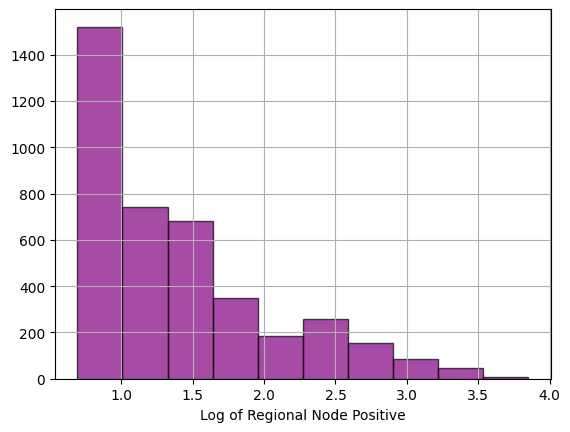

In [ ]:
np.log(df['Reginol Node Positive'] + 1).hist(bins=10, edgecolor='black', color='purple', alpha=0.7)
plt.xlabel('Log of Regional Node Positive')